<a href="https://colab.research.google.com/github/yashdeepspodder23/BlackHoleSimulations/blob/main/BHSim2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2008/1017306983.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  horizon_sphere = plt.Circle(bh_pos, Rs, color='#111111', edgecolor='red', lw=1.5, zorder=2, label='Event Horizon ($R_s$)')


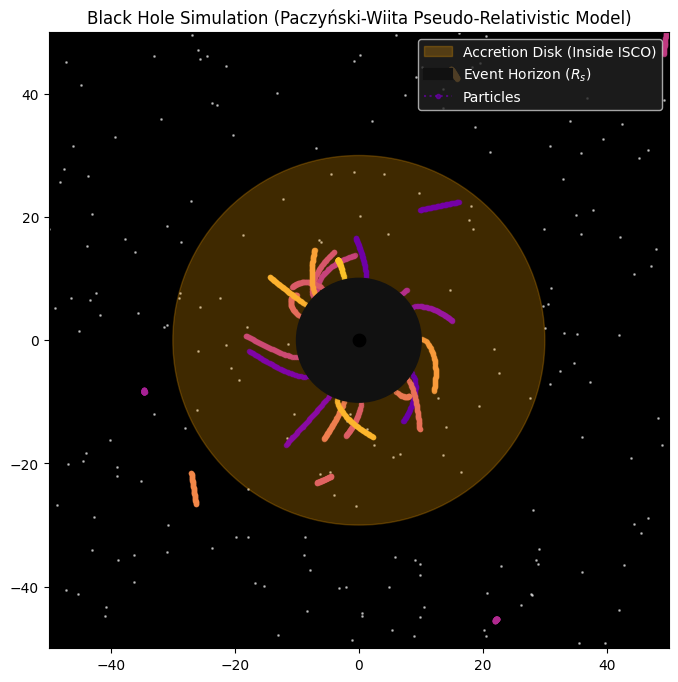

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import collections

# =====================================================================
# CONSTANTS & RELATIVISTIC PARAMETERS
# =====================================================================
G = 1        # Gravitational constant
M = 5.0      # Mass of the black hole (adjusted down from 100 for smoother scaling with Rs)
dt = 0.075    # Time step
num_p = 50   # Number of particles

# Paczyński-Wiita explicit parameters:
c = 1.0                  # Speed of light in geometrized units
Rs = (2.0 * G * M) / c**2 # Schwarzschild Radius (Event Horizon) ~ 10.0
R_isco = 3.0 * Rs        # Innermost Stable Circular Orbit ~ 30.0

# Initialize particle positions and velocities
np.random.seed(100)
# Spawn particles safely outside the event horizon to see orbits form
poss = np.random.uniform(-40, 40, (num_p, 2))
# Give particles a slight initial tangential velocity so they orbit instead of falling straight in
vel = np.random.uniform(-2, 2, (num_p, 2))

# Black hole position
bh_pos = np.array([0, 0])

# Global variables for trail
trail_length = 50
trail_data = [collections.deque(maxlen=trail_length) for _ in range(num_p)]

# =====================================================================
# PACZYŃSKI-WIITA FORCE CALCULATION
# =====================================================================
def grav_force_pw(pos):
    r = np.linalg.norm(pos - bh_pos)

    # Capture Condition: If particle is inside or exactly on the horizon,
    # it can no longer escape. Force spikes, so we flag it.
    if r <= Rs + 1e-3:
        return None

    # Paczyński-Wiita Gravitational Force Equation: F = GM / (r - Rs)^2
    f_mag = (G * M) / (r - Rs)**2
    dirn = (bh_pos - pos) / r
    return f_mag * dirn

# Update particle positions and velocities
def update_particles(poss, vel):
    for i in range(len(poss)):
        f = grav_force_pw(poss[i])

        if f is None:
            # Particle captured by Event Horizon: Lock it permanently at the singularity
            poss[i] = np.array([0.0, 0.0])
            vel[i] = np.array([0.0, 0.0])
        else:
            # Standard Euler-Cromer integration step
            vel[i] += f * dt
            poss[i] += vel[i] * dt

    return poss, vel

# =====================================================================
# PLOT & ACCRETION DISK LAYERING SETUP
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))
# Expanded viewing window to accommodate adjusted coordinate map
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_facecolor('black')

# Static background stars
num_stars = 200
star_x = np.random.uniform(-50, 50, num_stars)
star_y = np.random.uniform(-50, 50, num_stars)
ax.scatter(star_x, star_y, s=1, color='white', alpha=0.5, zorder=0)

# Accretion Disk mapped realistically to sit outside the event horizon
disk_radius = R_isco
accretion_disk = plt.Circle(bh_pos, disk_radius, color='orange', alpha=0.25, zorder=1, label='Accretion Disk (Inside ISCO)')
ax.add_patch(accretion_disk)

# Visualizing the True Horizon boundary
horizon_sphere = plt.Circle(bh_pos, Rs, color='#111111', edgecolor='red', lw=1.5, zorder=2, label='Event Horizon ($R_s$)')
ax.add_patch(horizon_sphere)

# Singularity Core
bh = plt.scatter(*bh_pos, color='black', s=80, zorder=3)

# Build trail lines
particles_trails = []
colors = plt.cm.plasma(np.linspace(0.2, 0.9, num_p)) # Plasma map looks highly energetic
for i in range(num_p):
    if i == 0:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=3, alpha=0.7, label='Particles', zorder=1.5)
    else:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=3, alpha=0.7, zorder=1.5)
    particles_trails.append(line)

ax.legend(loc='upper right', facecolor='#222222', labelcolor='white')
plt.title('Black Hole Simulation (Paczyński-Wiita Pseudo-Relativistic Model)', color='black')

# =====================================================================
# ANIMATION EXECUTOR LOOP
# =====================================================================
def init():
    for line in particles_trails:
        line.set_data([], [])
    return particles_trails

def animate(frame):
    global poss, vel
    poss, vel = update_particles(poss, vel)

    for i in range(num_p):
        # Stop tracking trails if the particle hits the center singularity
        if not np.all(poss[i] == 0.0):
            trail_data[i].append(poss[i].copy())

    artists_to_return = []
    for i, line in enumerate(particles_trails):
        x_coords = [p[0] for p in trail_data[i]]
        y_coords = [p[1] for p in trail_data[i]]
        line.set_data(x_coords, y_coords)
        artists_to_return.append(line)

    return artists_to_return

# Run and compile rendering pipeline
ani = FuncAnimation(fig, animate, frames=600, init_func=init, interval=20, blit=True)
#plt.show()

from IPython.display import HTML
html_animation = HTML(ani.to_html5_video())
display(html_animation)